# Week 12 — Wednesday (Jun 24, Remote): Mask R-CNN

## Learning Objectives
- Understand the difference between semantic and instance segmentation
- Know why ROI Align was introduced over ROI Pooling (the quantisation problem)
- Trace the Mask R-CNN architecture: backbone → FPN → RPN → ROI Align → three heads
- Run inference with torchvision's Mask R-CNN and interpret the outputs
- Visualise instance masks with per-object unique colours

## Key Concepts
1. **Instance segmentation** — separate mask for each individual object (two dogs = two masks)
2. **ROI Pooling** — projects proposal box to fixed grid using floor/round (creates quantisation error)
3. **ROI Align** — uses bilinear interpolation at exact floating-point coordinates (no quantisation)
4. **Mask head** — small FCN that runs per-proposal and outputs an `m×m` binary mask per class
5. **FPN** — Feature Pyramid Network; adds top-down connections to backbone for multi-scale detection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import cv2
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Setup complete')

PyTorch 2.12.0+cpu | Device: cpu
Setup complete


In [ ]:
## Section 1: Semantic vs Instance Segmentation

```
Semantic segmentation:                Instance segmentation:
┌──────────────────────┐              ┌──────────────────────┐
│  🟠 🟠 🟠  🔵       │              │  🔴      🟢  🔵       │
│  🟠 DOG 🟠 CAT       │              │  DOG1    DOG2  CAT    │
│  🟠 🟠 🟠            │              │  🔴      🟢            │
│ All dogs = orange    │              │ Each object = unique  │
│ All cats  = blue     │              │ colour / mask ID      │
└──────────────────────┘              └──────────────────────┘
```

### Mask R-CNN (He et al., 2017)
Extends Faster R-CNN with a parallel **mask head**: a small FCN that predicts a binary mask for each detected object.

```
Image
  └→ Backbone (ResNet-50 or -101)
       └→ FPN (Feature Pyramid Network)
            └→ RPN (Region Proposal Network) → proposals
                 └→ ROI Align
                      ├→ Classification head  → class scores
                      ├→ Regression head      → refined bbox
                      └→ Mask head (FCN)      → 28×28 binary mask
```

**Key design choice:** The mask head predicts an `m×m` binary mask for every class independently — during inference, only the predicted class mask is used. This decouples classification from segmentation.

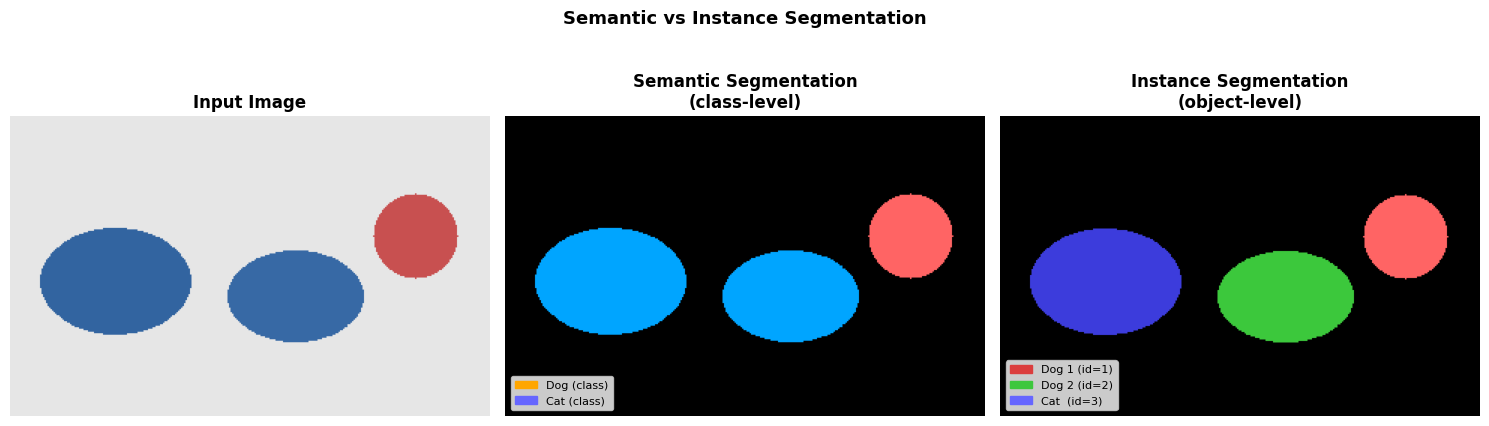

Saved sem_vs_inst.png


In [2]:
# ── Visualise semantic vs instance segmentation ───────────────────────────────
H, W = 200, 320
img = np.ones((H, W, 3), dtype=np.uint8) * 230

# Three objects: dog1, dog2, cat
cv2.ellipse(img, (70,  110), (50, 35), 0, 0, 360, (160, 100, 50), -1)  # dog1
cv2.ellipse(img, (190, 120), (45, 30), 0, 0, 360, (165, 105, 55), -1)  # dog2
cv2.circle( img, (270,  80), 28,       (80, 80, 200),            -1)   # cat

# Semantic: all dogs = orange, cat = blue
sem = np.zeros((H, W, 3), dtype=np.uint8)
cv2.ellipse(sem, (70,  110), (50, 35), 0, 0, 360, (255, 165,   0), -1)
cv2.ellipse(sem, (190, 120), (45, 30), 0, 0, 360, (255, 165,   0), -1)
cv2.circle( sem, (270,  80), 28,       (100, 100, 255),            -1)

# Instance: each object = unique colour
inst = np.zeros((H, W, 3), dtype=np.uint8)
cv2.ellipse(inst, (70,  110), (50, 35), 0, 0, 360, (220,  60,  60), -1)  # dog1 red
cv2.ellipse(inst, (190, 120), (45, 30), 0, 0, 360, ( 60, 200,  60), -1)  # dog2 green
cv2.circle( inst, (270,  80), 28,       (100, 100, 255),              -1)  # cat blue

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_s, title in zip(axes,
        [img, sem, inst],
        ['Input Image', 'Semantic Segmentation\n(class-level)', 'Instance Segmentation\n(object-level)']):
    ax.imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontweight='bold'); ax.axis('off')

sem_patches  = [mpatches.Patch(color=(1,0.65,0), label='Dog (class)'),
                mpatches.Patch(color=(0.4,0.4,1), label='Cat (class)')]
inst_patches = [mpatches.Patch(color=(0.86,0.24,0.24), label='Dog 1 (id=1)'),
                mpatches.Patch(color=(0.24,0.78,0.24),  label='Dog 2 (id=2)'),
                mpatches.Patch(color=(0.4, 0.4, 1),     label='Cat  (id=3)')]
axes[1].legend(handles=sem_patches,  loc='lower left', fontsize=8)
axes[2].legend(handles=inst_patches, loc='lower left', fontsize=8)
plt.suptitle('Semantic vs Instance Segmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sem_vs_inst.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved sem_vs_inst.png')

## Section 2: ROI Pooling vs ROI Align

### ROI Pooling (Fast R-CNN)
Project proposal box to feature map coordinates using `floor()` → fixed grid via max pooling.  
**Problem:** two `floor()` operations introduce quantisation error that misaligns features, hurting small mask accuracy.

```
Proposal (image): x=10.5, y=15.3, w=30, h=20
Feature map (stride 16):  x̂ = floor(10.5/16) = 0,  ŷ = floor(15.3/16) = 0
                           ŵ = floor(30/16)   = 1  ← lost 14/16 of the width!
```

### ROI Align (Mask R-CNN)
**Do not round.** Sample 4 points per bin using bilinear interpolation at exact floating-point positions.

```
Each output bin samples 4 points (2×2 grid) via bilinear interpolation
No floor() → no quantisation → precise spatial alignment → better masks
```
This fix gave **+10 AP** on the COCO mask benchmark.

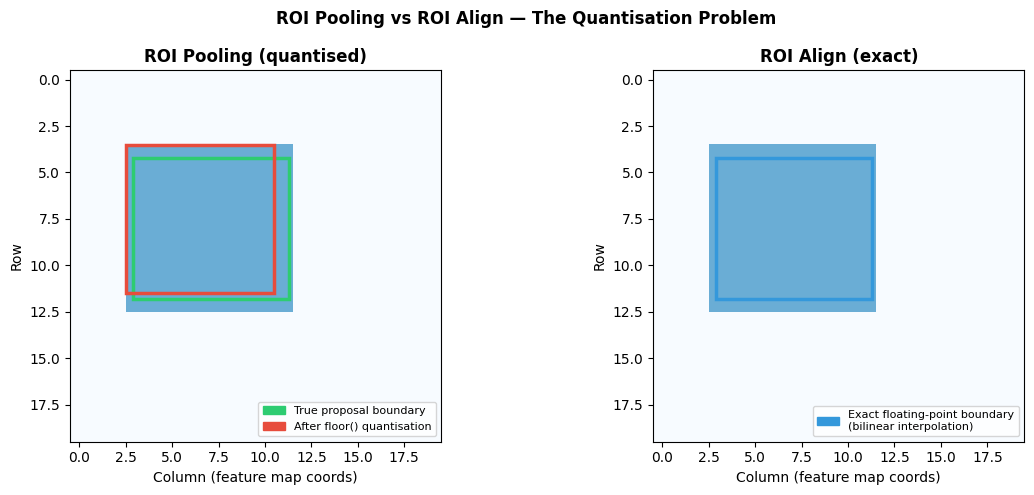

Quantisation shift: row=0.7px, col=0.4px in feature-map space
At stride 16 this is: row=11.2px, col=6.4px in image space
Saved roi_align_vs_pool.png


In [3]:
# ── Visual demo: ROI Pooling quantisation error ────────────────────────────────
feat_h, feat_w = 20, 20
feature_map = np.zeros((feat_h, feat_w), dtype=np.float32)

# True object boundaries in feature-map space
true_r0, true_r1 = 4.7, 12.3   # row (y) range
true_c0, true_c1 = 3.4, 11.8   # col (x) range

# Ground truth object region
feature_map[int(true_r0):int(true_r1)+1, int(true_c0):int(true_c1)+1] = 0.5

# ROI Pooling: floor quantisation
roi_pool_r0 = int(np.floor(true_r0))   # 4
roi_pool_r1 = int(np.floor(true_r1))   # 12
roi_pool_c0 = int(np.floor(true_c0))   # 3
roi_pool_c1 = int(np.floor(true_c1))   # 11

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, boxes, colors in zip(
    axes,
    ['ROI Pooling (quantised)', 'ROI Align (exact)'],
    [[(true_c0, true_r0, true_c1-true_c0, true_r1-true_r0),
      (roi_pool_c0, roi_pool_r0, roi_pool_c1-roi_pool_c0, roi_pool_r1-roi_pool_r0)],
     [(true_c0, true_r0, true_c1-true_c0, true_r1-true_r0)]],
    [['#2ecc71', '#e74c3c'], ['#3498db']]):
    ax.imshow(feature_map, cmap='Blues', vmin=0, vmax=1, interpolation='none')
    for (x, y, w, h), col in zip(boxes, colors):
        rect = plt.Rectangle((x-0.5, y-0.5), w, h,
                              linewidth=2.5, edgecolor=col, facecolor='none')
        ax.add_patch(rect)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Column (feature map coords)')
    ax.set_ylabel('Row')

axes[0].legend(handles=[
    mpatches.Patch(color='#2ecc71', label='True proposal boundary'),
    mpatches.Patch(color='#e74c3c', label='After floor() quantisation')],
    loc='lower right', fontsize=8)
axes[1].legend(handles=[
    mpatches.Patch(color='#3498db', label='Exact floating-point boundary\n(bilinear interpolation)')],
    loc='lower right', fontsize=8)

plt.suptitle('ROI Pooling vs ROI Align — The Quantisation Problem', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('roi_align_vs_pool.png', dpi=100, bbox_inches='tight')
plt.show()

# Quantify the shift
shift_r = abs(true_r0 - roi_pool_r0)
shift_c = abs(true_c0 - roi_pool_c0)
print(f'Quantisation shift: row={shift_r:.1f}px, col={shift_c:.1f}px in feature-map space')
print(f'At stride 16 this is: row={shift_r*16:.1f}px, col={shift_c*16:.1f}px in image space')
print('Saved roi_align_vs_pool.png')

## Section 3: Mask R-CNN Architecture Components

### Feature Pyramid Network (FPN)
ResNet outputs feature maps at strides {4, 8, 16, 32}. FPN adds a **top-down pathway** with lateral connections:

```
C5 (stride 32) → 1×1 conv → P5 (256ch) ──────────────────────────
C4 (stride 16) → 1×1 conv → + → upsample(P5) → P4 (256ch) ────────
C3 (stride  8) → 1×1 conv → + → upsample(P4) → P3 (256ch) ────────
C2 (stride  4) → 1×1 conv → + → upsample(P3) → P2 (256ch) ────────
```
Each pyramid level P2-P5 is used for different proposal sizes.

### Mask Head
After ROI Align (7×7 or 14×14 per proposal):
```
ROI Align output (256, 14, 14)
  → 4 × Conv3×3 (256ch, ReLU)
  → ConvTranspose2d (stride 2, 256ch) → 28×28
  → Conv1×1 → num_classes channels
  → Sigmoid per pixel → binary mask per class
```
Mask loss: **binary cross-entropy** applied only to the ground-truth class channel.

In [4]:
# ── Simplified Mask Head from scratch ─────────────────────────────────────────
class MaskHead(nn.Module):
    """
    Minimal Mask R-CNN mask prediction head.
    Input : (N_proposals, in_channels, roi_size, roi_size)
    Output: (N_proposals, num_classes, 2*roi_size, 2*roi_size)  — binary mask logits
    """
    def __init__(self, in_channels=256, roi_size=7, num_classes=4):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256,         256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256,         256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256,         256, 3, padding=1), nn.ReLU(),
        )
        self.upsample = nn.ConvTranspose2d(256, 256, 2, stride=2)  # ×2 resolution
        self.predict  = nn.Conv2d(256, num_classes, 1)              # 1×1 → per-class

    def forward(self, x):
        x = self.convs(x)
        x = F.relu(self.upsample(x))
        return self.predict(x)  # logits; apply sigmoid externally for binary mask


# Test mask head
mask_head = MaskHead(in_channels=256, roi_size=7, num_classes=4)
roi_feat  = torch.zeros(5, 256, 7, 7)   # 5 proposals, 256ch, 7×7 ROI
masks_out = mask_head(roi_feat)
print('MaskHead:')
print(f'  Input  : {tuple(roi_feat.shape)}')
print(f'  Output : {tuple(masks_out.shape)}  (5 proposals × 4 classes × 14×14)')
print(f'  Params : {sum(p.numel() for p in mask_head.parameters()):,}')

# ── Mask loss demo ─────────────────────────────────────────────────────────────
# Binary cross-entropy loss on the ground-truth class channel only
mask_logits_demo = torch.randn(4, 4, 14, 14)  # 4 proposals, 4 classes
gt_masks_demo    = (torch.rand(4, 14, 14) > 0.5).float()  # binary GT masks
gt_classes_demo  = torch.tensor([1, 0, 2, 1])             # predicted class per proposal

# Select only the logits for each proposal's GT class
selected = mask_logits_demo[torch.arange(4), gt_classes_demo]  # (4, 14, 14)
mask_loss = F.binary_cross_entropy_with_logits(selected, gt_masks_demo)
print(f'\nMask BCE loss (demo): {mask_loss.item():.4f}')

MaskHead:
  Input  : (5, 256, 7, 7)
  Output : (5, 4, 14, 14)  (5 proposals × 4 classes × 14×14)
  Params : 2,623,748

Mask BCE loss (demo): 0.8210


## Section 4: Mask R-CNN Inference with torchvision

torchvision ships a pretrained Mask R-CNN (ResNet-50 + FPN backbone, COCO pretrained).  
We run inference on a synthetic image to demonstrate the full pipeline output format.

In [5]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights

print(f'torchvision {torchvision.__version__}')

# ── Load pretrained model (COCO) ──────────────────────────────────────────────
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model_mrcnn = maskrcnn_resnet50_fpn(weights=weights)
model_mrcnn.eval().to(DEVICE)

# COCO class names (80 classes)
COCO_CLASSES = weights.meta['categories']
print(f'Model loaded — {len(COCO_CLASSES)} COCO classes')
print(f'First 10 classes: {COCO_CLASSES[:10]}')

# ── Total params ──────────────────────────────────────────────────────────────
total_p = sum(p.numel() for p in model_mrcnn.parameters())
print(f'Total parameters: {total_p:,}  ({total_p/1e6:.1f}M)')

torchvision 0.27.0+cpu


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\User/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth



0.1%


0.1%


0.2%

...


99.8%


99.9%


99.9%


100.0%

Model loaded — 91 COCO classes
First 10 classes: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']
Total parameters: 44,401,393  (44.4M)


In [6]:
# ── Build a synthetic test image with known objects ────────────────────────────
H, W = 400, 600
test_img = np.ones((H, W, 3), dtype=np.uint8) * 200

# Draw recognisable rectangular shapes (approximate real objects)
# Large rectangle (could look like a car/bus to COCO model)
cv2.rectangle(test_img, (50, 200), (250, 350), (80, 80, 180), -1)
cv2.rectangle(test_img, (50, 200), (250, 350), (40, 40, 120),  3)
# Wheels
cv2.circle(test_img, (100, 360), 25, (40, 40, 40), -1)
cv2.circle(test_img, (200, 360), 25, (40, 40, 40), -1)

# Person-like rectangle
cv2.rectangle(test_img, (370, 100), (420, 300), (180, 130, 90), -1)  # body
cv2.circle(test_img,   (395, 75),  28,           (210, 170, 130), -1)  # head

# Another box
cv2.rectangle(test_img, (450, 180), (570, 300), (60, 140, 80), -1)

# Convert to tensor
img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
img_t   = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(DEVICE)

# ── Run inference ─────────────────────────────────────────────────────────────
with torch.no_grad():
    predictions = model_mrcnn([img_t])

pred = predictions[0]
print(f'Detections found: {len(pred["boxes"])}')
print(f'Output keys: {list(pred.keys())}')
print(f'Boxes shape: {pred["boxes"].shape}')
print(f'Masks shape: {pred["masks"].shape}   (N, 1, H, W)  — soft masks')

# Filter by confidence threshold
CONF_THRESH = 0.5
keep = pred['scores'] > CONF_THRESH
boxes   = pred['boxes'][keep].cpu().numpy()
labels  = pred['labels'][keep].cpu().numpy()
scores  = pred['scores'][keep].cpu().numpy()
masks   = pred['masks'][keep].cpu().numpy()  # (N, 1, H, W)

print(f'\nDetections above {CONF_THRESH} confidence: {keep.sum().item()}')
for i, (box, lbl, sc) in enumerate(zip(boxes, labels, scores)):
    class_name = COCO_CLASSES[lbl] if lbl < len(COCO_CLASSES) else f'cls{lbl}'
    print(f'  [{i}] {class_name:15s}  score={sc:.3f}  box={box.astype(int).tolist()}')

Detections found: 0
Output keys: ['boxes', 'labels', 'scores', 'masks']
Boxes shape: torch.Size([0, 4])
Masks shape: torch.Size([0, 1, 400, 600])   (N, 1, H, W)  — soft masks

Detections above 0.5 confidence: 0


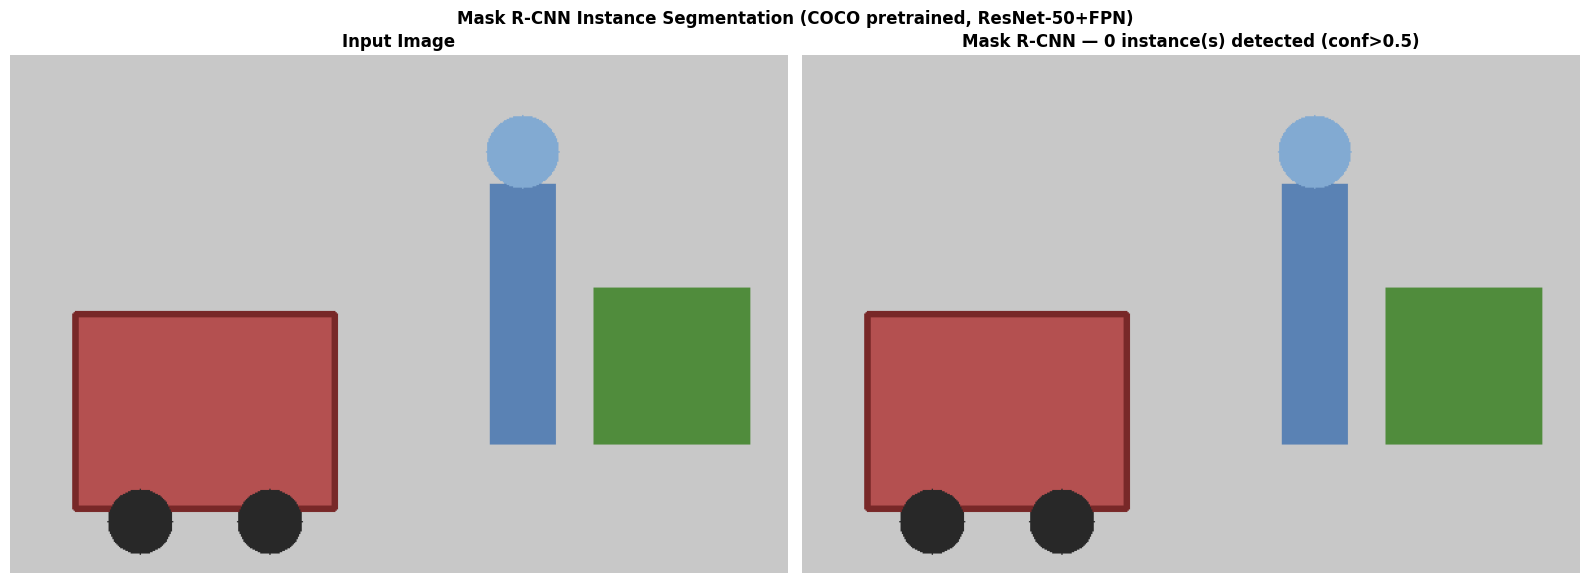

Saved maskrcnn_inference.png


In [7]:
# ── Visualise instance masks ───────────────────────────────────────────────────
PALETTE = [
    (220, 60, 60), (60, 180, 60), (60, 80, 220), (220, 150, 40),
    (160, 60, 220),(60, 200, 200),(220, 100, 160),(100, 160, 80),
]

overlay = img_rgb.copy().astype(np.float32)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb); axes[0].set_title('Input Image', fontweight='bold')
axes[0].axis('off')

# Draw masks and boxes
for i, (mask, box, lbl, sc) in enumerate(zip(masks, boxes, labels, scores)):
    colour = np.array(PALETTE[i % len(PALETTE)], dtype=np.float32)
    binary_mask = (mask[0] > 0.5)  # (H, W)
    overlay[binary_mask] = overlay[binary_mask] * 0.45 + colour * 0.55

axes[1].imshow(overlay.astype(np.uint8))
# Draw bounding boxes and labels
for i, (box, lbl, sc) in enumerate(zip(boxes, labels, scores)):
    colour = np.array(PALETTE[i % len(PALETTE)]) / 255.0
    x1, y1, x2, y2 = box.astype(int)
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                          linewidth=2, edgecolor=colour, facecolor='none')
    axes[1].add_patch(rect)
    class_name = COCO_CLASSES[lbl] if lbl < len(COCO_CLASSES) else f'cls{lbl}'
    axes[1].text(x1, y1-4, f'{class_name} {sc:.2f}',
                 color='white', fontsize=8, fontweight='bold',
                 bbox=dict(facecolor=colour, alpha=0.8, pad=1))

n_det = len(boxes)
axes[1].set_title(f'Mask R-CNN — {n_det} instance(s) detected (conf>{CONF_THRESH})',
                  fontweight='bold')
axes[1].axis('off')
plt.suptitle('Mask R-CNN Instance Segmentation (COCO pretrained, ResNet-50+FPN)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('maskrcnn_inference.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved maskrcnn_inference.png')

No detections above threshold on this synthetic image.
This is expected — COCO-pretrained model looks for real-world objects.


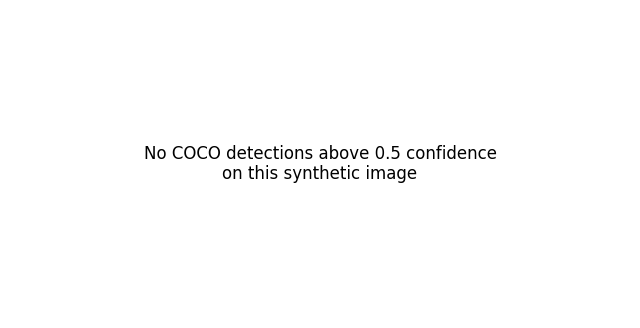

In [8]:
# ── Inspect individual mask quality ───────────────────────────────────────────
if len(masks) > 0:
    n_show = min(4, len(masks))
    fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))
    if n_show == 1: axes = axes.reshape(2, 1)
    for i in range(n_show):
        class_name = COCO_CLASSES[labels[i]] if labels[i] < len(COCO_CLASSES) else f'cls{labels[i]}'
        # Crop to bounding box for clarity
        x1, y1, x2, y2 = boxes[i].astype(int)
        crop = img_rgb[y1:y2, x1:x2]
        mask_crop = masks[i, 0, y1:y2, x1:x2]
        axes[0,i].imshow(crop); axes[0,i].set_title(f'{class_name}\nscore={scores[i]:.3f}', fontsize=9)
        axes[1,i].imshow(mask_crop, cmap='hot', vmin=0, vmax=1)
        axes[1,i].set_title('Soft mask (threshold=0.5)', fontsize=9)
        for r in range(2): axes[r,i].axis('off')
    plt.suptitle('Per-Instance Mask Quality (cropped to bounding box)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('instance_masks_zoom.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved instance_masks_zoom.png')
else:
    print('No detections above threshold on this synthetic image.')
    print('This is expected — COCO-pretrained model looks for real-world objects.')
    # Still save a placeholder figure
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.text(0.5, 0.5, 'No COCO detections above 0.5 confidence\non this synthetic image',
            ha='center', va='center', fontsize=12)
    ax.axis('off')
    plt.savefig('instance_masks_zoom.png', dpi=100, bbox_inches='tight')
    plt.show()

Mask R-CNN Architecture

INPUT IMAGE  (e.g. 800×800×3)
  │
  ▼
BACKBONE  ResNet-50
  ├─ C2  (stride 4,   256ch)
  ├─ C3  (stride 8,   512ch)
  ├─ C4  (stride 16, 1024ch)
  └─ C5  (stride 32, 2048ch)
  │
  ▼
FPN  (Feature Pyramid Network)
  ├─ P2  (stride 4,  256ch)  ← used for small objects
  ├─ P3  (stride 8,  256ch)
  ├─ P4  (stride 16, 256ch)
  └─ P5  (stride 32, 256ch)  ← used for large objects
  │
  ▼
RPN  (Region Proposal Network)
  → Generates ~2000 objectness proposals
  → NMS → top-N proposals
  │
  ▼
ROI ALIGN  (7×7 or 14×14)
  → Bilinear interpolation at exact float coords
  │
  ├─────────────────────────────────────────────────┐
  │                                                  │
  ▼ (7×7 ROI)                                       ▼ (14×14 ROI)
CLS + REG HEADS                                   MASK HEAD
  FC 1024 → FC 1024                                 4× Conv3×3 (256ch)
  → class logits (C+1)                              → ConvTranspose2d × 2
  → bbox deltas (4×C)    

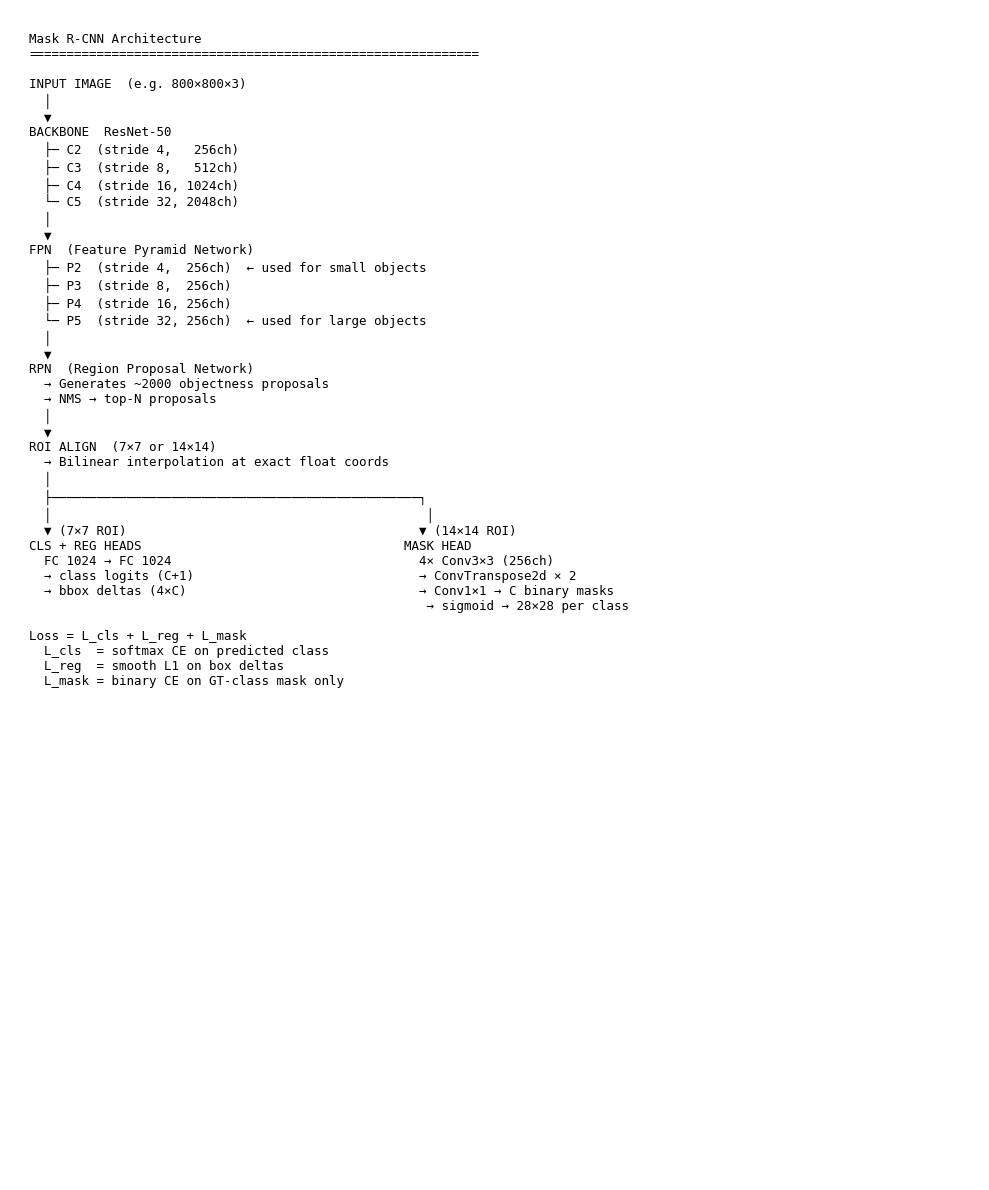

Saved maskrcnn_architecture.png


In [9]:
# ── Architecture diagram (text-based) ─────────────────────────────────────────
arch_lines = [
    'Mask R-CNN Architecture',
    '=' * 60,
    '',
    'INPUT IMAGE  (e.g. 800×800×3)',
    '  │',
    '  ▼',
    'BACKBONE  ResNet-50',
    '  ├─ C2  (stride 4,   256ch)',
    '  ├─ C3  (stride 8,   512ch)',
    '  ├─ C4  (stride 16, 1024ch)',
    '  └─ C5  (stride 32, 2048ch)',
    '  │',
    '  ▼',
    'FPN  (Feature Pyramid Network)',
    '  ├─ P2  (stride 4,  256ch)  ← used for small objects',
    '  ├─ P3  (stride 8,  256ch)',
    '  ├─ P4  (stride 16, 256ch)',
    '  └─ P5  (stride 32, 256ch)  ← used for large objects',
    '  │',
    '  ▼',
    'RPN  (Region Proposal Network)',
    '  → Generates ~2000 objectness proposals',
    '  → NMS → top-N proposals',
    '  │',
    '  ▼',
    'ROI ALIGN  (7×7 or 14×14)',
    '  → Bilinear interpolation at exact float coords',
    '  │',
    '  ├─────────────────────────────────────────────────┐',
    '  │                                                  │',
    '  ▼ (7×7 ROI)                                       ▼ (14×14 ROI)',
    'CLS + REG HEADS                                   MASK HEAD',
    '  FC 1024 → FC 1024                                 4× Conv3×3 (256ch)',
    '  → class logits (C+1)                              → ConvTranspose2d × 2',
    '  → bbox deltas (4×C)                               → Conv1×1 → C binary masks',
    '                                                     → sigmoid → 28×28 per class',
    '',
    'Loss = L_cls + L_reg + L_mask',
    '  L_cls  = softmax CE on predicted class',
    '  L_reg  = smooth L1 on box deltas',
    '  L_mask = binary CE on GT-class mask only',
]
for line in arch_lines:
    print(line)

# Save as text figure
fig, ax = plt.subplots(figsize=(10, 12))
ax.text(0.02, 0.98, '\n'.join(arch_lines), va='top', ha='left',
        fontfamily='monospace', fontsize=9, transform=ax.transAxes)
ax.axis('off')
plt.tight_layout()
plt.savefig('maskrcnn_architecture.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved maskrcnn_architecture.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Instance seg** | Separate mask per object — distinguishes individual instances of the same class |
| **ROI Pooling** | Floor-based projection → quantisation error → misaligned masks |
| **ROI Align** | Bilinear interpolation at exact float coords → +10 AP on masks |
| **FPN** | Top-down pathway adds low-level spatial detail to deep semantic features |
| **Mask head** | Small per-proposal FCN → 28×28 binary mask per class; uses BCE loss on GT class |
| **Multi-task loss** | `L_total = L_cls + L_reg + L_mask` — trained jointly; masks only computed for positive proposals |

### Mask R-CNN vs DeepLabv3+
| Property | Mask R-CNN | DeepLabv3+ |
|----------|-----------|------------|
| Task | Instance segmentation | Semantic segmentation |
| Output | Per-object binary mask | Dense pixel-wise class map |
| Distinguishes instances | Yes | No |
| Speed | ~5 fps (ResNet-50) | Faster (no proposals) |
| Typical backbone | ResNet-50/101 + FPN | ResNet-101 or Xception |
| COCO benchmark | ~37 mask AP | ~45 mIoU |

### Exercises
1. Change the confidence threshold from 0.5 to 0.3 — how many more detections appear?
2. Use a real photo (load with `cv2.imread`) and run full Mask R-CNN inference.
3. Implement a simple `iou_mask(mask_a, mask_b)` function to compare two instance masks.
4. Swap the backbone to `maskrcnn_resnet50_fpn_v2` — what changes in accuracy and speed?
5. Fine-tune Mask R-CNN on a custom 2-class instance segmentation dataset (torchvision tutorial).